<a href="https://colab.research.google.com/github/yawarabbasmalik/Red-Wine-Quality-Exploration-/blob/main/Red_Wine_Quality_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Data Preparation and Analysis


## Task 1.1


In [ ]:
# install all the required packages
!pip3 install pandas scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

#### Create the data random sample

In [ ]:
# # Load the csv file into a dataframe
# df = pd.read_csv('A2data.csv', sep=';') # read the csv file into a dataframe
# df = df.dropna() # drop all rows with missing values

# # Randomly sample 600 instances from the dataframe
# df = df.sample(n=600) # take a random sample of 600 instances
# df.to_csv('A2RandomSample.csv', index=False) # write the random sample into a CSV file

#### Load the data frome the random sample file

In [ ]:
# Load the csv file into a dataframe
df = pd.read_csv('A2RandomSample.csv', sep=',')

df.shape # check the shape/size of the dataframe

(600, 12)

In [ ]:
# Print the first 5 rows of the dataframe
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,5.7,0.21,0.24,2.3,0.047,60.0,189.0,0.99500,3.65,0.72,10.1,6
1,6.6,0.18,0.26,17.3,0.051,17.0,149.0,0.99840,3.00,0.43,9.4,6
2,7.4,0.56,0.09,1.5,0.071,19.0,117.0,0.99496,3.22,0.53,9.8,5
3,7.2,0.24,0.30,1.6,0.048,27.0,131.0,0.99330,3.25,0.45,10.5,5
4,5.6,0.35,0.37,1.0,0.038,6.0,72.0,0.99020,3.37,0.34,11.4,5


In [ ]:
# Check the data types of the columns
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [ ]:
# Convert residual sugar, free sulfur dioxide, total sulfur dioxide, density column to nuberic type
df['residual sugar'] = pd.to_numeric(df['residual sugar'], errors='coerce')
df['free sulfur dioxide'] = pd.to_numeric(df['free sulfur dioxide'], errors='coerce')
df['total sulfur dioxide'] = pd.to_numeric(df['total sulfur dioxide'], errors='coerce')
df['density'] = pd.to_numeric(df['density'], errors='coerce')

# Check the data types of the columns
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [ ]:
# Count the NaN values in each column
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [ ]:
df.describe() # get the summary statistics of the dataframe

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,6.882833,0.278033,0.334350,6.443500,0.046973,36.083333,140.785833,0.994115,3.184883,0.493983,10.467900,5.820000
std,0.801994,0.097468,0.130523,5.036595,0.025252,16.449845,44.142095,0.002877,0.147782,0.112704,1.195027,0.899416
min,4.900000,0.110000,0.000000,0.700000,0.018000,4.000000,19.000000,0.987940,2.790000,0.250000,8.500000,3.000000
25%,6.400000,0.220000,0.260000,1.700000,0.036000,24.000000,109.000000,0.991772,3.080000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.275000,0.044000,34.000000,138.000000,0.993800,3.180000,0.480000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,10.325000,0.051000,48.000000,173.000000,0.996005,3.270000,0.550000,11.400000,6.000000
max,9.400000,0.905000,1.660000,22.000000,0.346000,105.000000,366.500000,1.001820,3.800000,0.980000,14.050000,9.000000


## Task 1.2

Explore the relationship between two variables: alcohol and density.

Intercept:  [332.99396791]
Slope:  [[-324.43553324]]
R2:  0.609925059509325


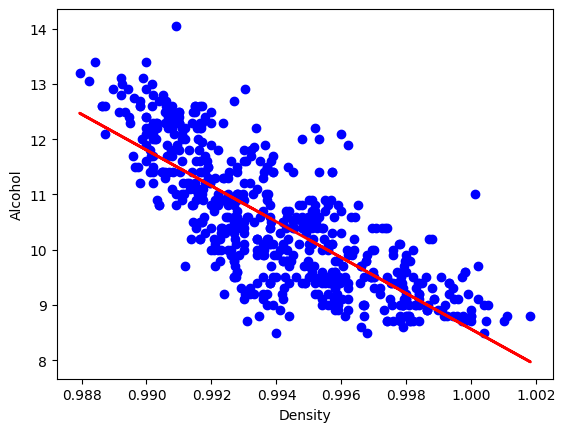

In [ ]:
# Build a linear model for the two variables
# Reshape the array to a 2D array
X = np.array(df['density']).reshape(-1,1)
y = np.array(df['alcohol']).reshape(-1,1)

# Create a linear regression object
lm = LinearRegression()

# Fit the linear regression model
lm.fit(X,y)

# Predict the alcohol values using the model
yhat = lm.predict(X)

# Print the intercept and slope of the model and the R2 value
print('Intercept: ', lm.intercept_)
print('Slope: ', lm.coef_)
print('R2: ', lm.score(X,y))

# Plot the linear regression model
plt.scatter(X, y,  color='blue')
plt.plot(X, yhat, color='red', linewidth=2)
plt.xlabel("Density")
plt.ylabel("Alcohol")
plt.show()

## Task 1.3


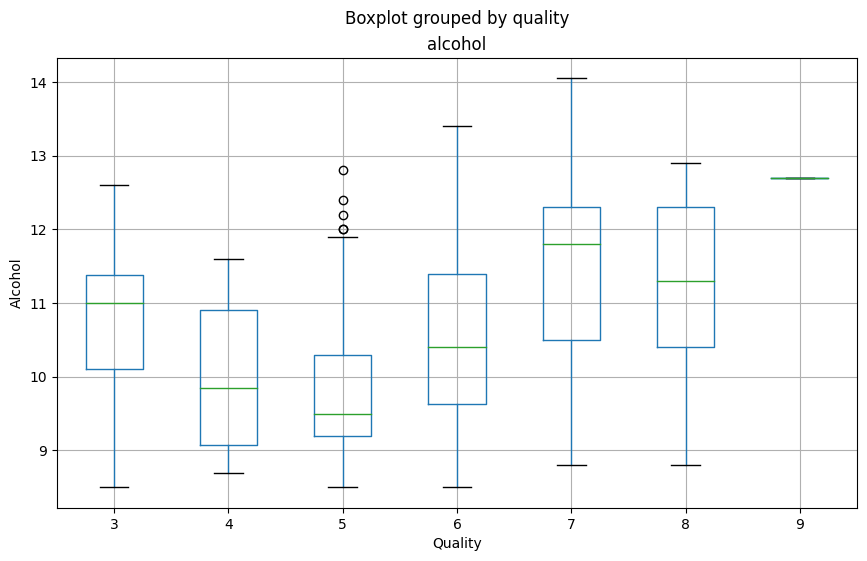

In [ ]:
# Explore the relationship between two variables: quality and alcohol.

# Create a boxplot for alcohol grouped by quality level
df.boxplot(column='alcohol', by='quality', figsize=(10,6))
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

# TODO: Summarise your findings based on the boxplot.


# Task 2: Classification

## Task 2.1

Accuracy: 0.3888888888888889
Precision: 0.4411209763578715
Recall: 0.3888888888888889
[[ 0  0  0  1  2  1  0]
 [ 0  0  2  2  1  0  0]
 [ 2  3 25 15  6  0  0]
 [ 1  1 33 37 16  5  2]
 [ 0  1  4  8  5  1  0]
 [ 0  0  1  1  1  3  0]
 [ 0  0  0  0  0  0  0]]


/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


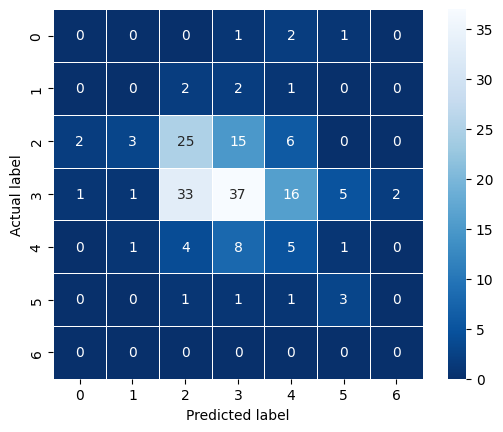

In [ ]:
# Create a Decision Tree model.
# Train and evaluate the model appropriately.
# Use at least 3 metrics for evaluation


# Create a dataframe with the required columns
df2 = df[['alcohol', 'density', 'quality']]
df2.head()

# Create a feature matrix X and a response vector y
X = df2[['alcohol', 'density']]
y = df2['quality']

# Split the dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Create a Decision Tree Classifier object
clf = DecisionTreeClassifier()

# Train the model using the training sets
clf.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = clf.predict(X_test)

# Evaluate the model
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred, average='weighted'))
print("Recall:", metrics.recall_score(y_test, y_pred, average='weighted'))

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)
print(cm)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()


## Task 2.2

Accuracy: 0.45555555555555555
Precision: 0.46152421652421644
Recall: 0.45555555555555555
[[ 0  0  0  2  2  0]
 [ 0  0  4  1  0  0]
 [ 1  0 35 14  1  0]
 [ 0  0 39 45 11  0]
 [ 0  0  5 13  1  0]
 [ 0  0  2  3  0  1]]


/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


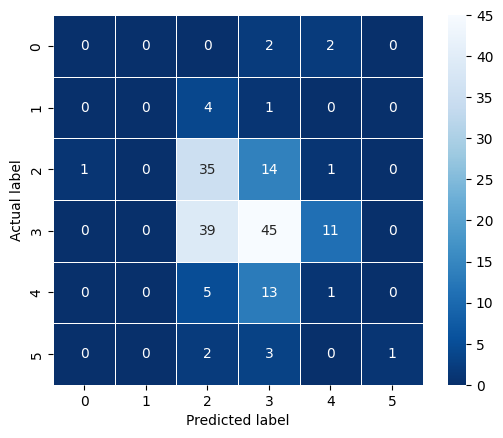

In [ ]:
# Study the impact of at least one key parameter of the model. Describe your findings. Choose the best value(s) for the parameter(s) and justify your choice.

# Create a Decision Tree Classifier object
clf = DecisionTreeClassifier(max_depth=5)

# Train the model using the training sets
clf.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = clf.predict(X_test)

# Evaluate the model
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred, average='weighted'))
print("Recall:", metrics.recall_score(y_test, y_pred, average='weighted'))

# Create a confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)
print(cm)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

## Task 2.3

/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/khoraidah/Library/Python/3.9/lib/

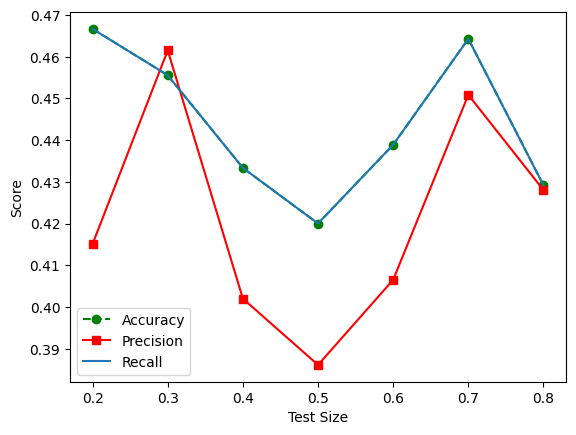

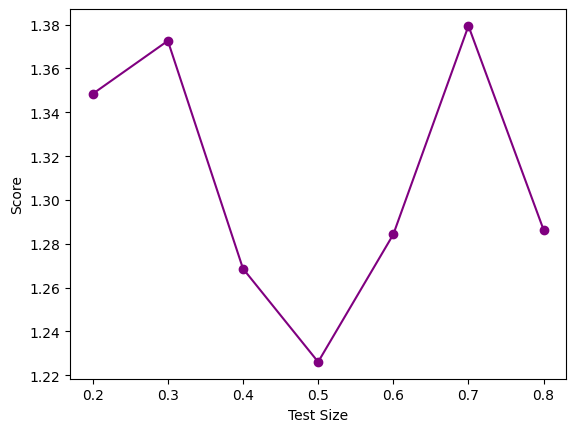

Best train/test split
Test:  %70
Train:  %30


In [ ]:
# With the above optimal parameter(s), train and test the model on different training/test data splits: 20:80, 30:70, 40:60, 50:50, 60:40, 70:30, 80:20.
# Plot the accuracy, precision and recall values for each split on the same graph.

# Create a dataframe with the required columns
df2 = df[['alcohol', 'density', 'quality']]

# Create a feature matrix X and a response vector y
X = df2[['alcohol', 'density']]
y = df2['quality']

# Create a list of test sizes split
test_sizes = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Create lists to store the accuracy, precision and recall values
accuracy = []
precision = []
recall = []

# Iterate through the test sizes
for test_size in test_sizes:
    # Split the dataset into training set and test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=0)

    # Create a Decision Tree Classifier object
    clf = DecisionTreeClassifier(max_depth=5)

    # Train the model using the training sets
    clf.fit(X_train, y_train)

    # Predict the response for test dataset
    y_pred = clf.predict(X_test)

    # Evaluate the model
    accuracy.append(metrics.accuracy_score(y_test, y_pred))
    precision.append(metrics.precision_score(y_test, y_pred, average='weighted'))
    recall.append(metrics.recall_score(y_test, y_pred, average='weighted'))

# Plot the accuracy, precision and recall values for each split on the same graph
plt.plot(test_sizes, accuracy, label='Accuracy', color='green', linestyle='dashed', marker='o')
plt.plot(test_sizes, precision, label='Precision', color='red', marker='s')
plt.plot(test_sizes, recall, label='Recall')
plt.xlabel('Test Size')
plt.ylabel('Score')
plt.legend()
plt.show()


# Summarise your findings:
# Get best train/test split because that has the total highest accuracy, precision and recall values
results = []
for i in range(len(accuracy)):
    result = accuracy[i] + precision[i] + recall[i]
    results.append(result)

# Plot the results
plt.plot(test_sizes, results, label='Results', color='purple', marker='o')
plt.xlabel('Test Size')
plt.ylabel('Score')
plt.show()


best_index = results.index(max(results)) # Get the index of the best result
print('Best train/test split') # Get the best train/test split
print('Test: ', '%'+ str(round(test_sizes[best_index]*100)))
print('Train: ', '%'+ str((round(100-(test_sizes[best_index]*100)))))

# Task 3: Clustering

## Task 3.1

/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/cluste

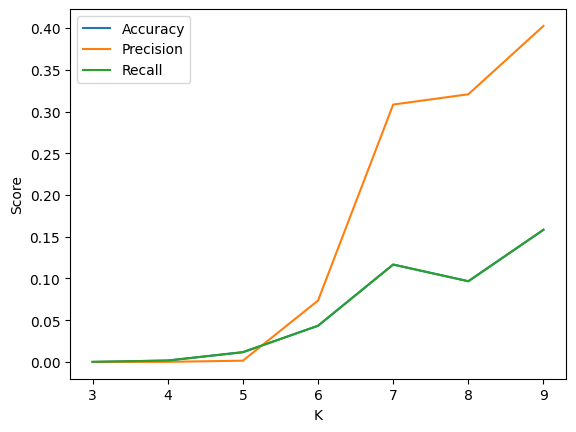

In [ ]:
# Clustering:
# k-means Build and evaluate the model. Tune the key parameter(s) of the model and justify your choice of the value(s).
from sklearn.cluster import KMeans

# Create a dataframe with the required columns
df3 = df[['alcohol', 'density', 'quality']]

# Create a feature matrix X and a response vector y
X = df3[['alcohol', 'density']]
y = df3['quality']

# Create a list of k values
k_values = df3['quality'].sort_values().unique()

# Create lists to store the accuracy, precision and recall values
accuracy = []
precision = []
recall = []

# Iterate through the k values
for k in k_values:
    # Create a KMeans object
    kmeans = KMeans(n_clusters=k, random_state=0)

    # Train the model using the training sets
    kmeans.fit(X)

    # Predict the response for test dataset
    y_pred = kmeans.predict(X)

    # Evaluate the model
    accuracy.append(metrics.accuracy_score(y, y_pred))
    precision.append(metrics.precision_score(y, y_pred, average='weighted'))
    recall.append(metrics.recall_score(y, y_pred, average='weighted'))

# Plot the accuracy, precision and recall values for each split on the same graph
plt.plot(k_values, accuracy, label='Accuracy')
plt.plot(k_values, precision, label='Precision')
plt.plot(k_values, recall, label='Recall')
plt.xlabel('K')
plt.ylabel('Score')
plt.legend()
plt.show()



## Task 3.2

/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Best k value:  9


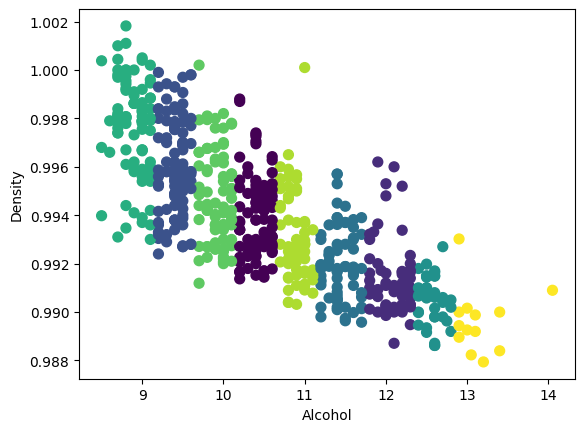

In [ ]:
# Determine the optimal number of clusters:
# Get best k value because that has the total highest accuracy, precision and recall values
results = []
for i in range(len(accuracy)):
    result = accuracy[i] + precision[i] + recall[i]
    results.append(result)

best_index = results.index(max(results)) # Get the index of the best result
print('Best k value: ', k_values[best_index]) # Get the best k value

# Plot the clusters
# Create a KMeans object
kmeans = KMeans(n_clusters=k_values[best_index], random_state=0)

# Train the model using the training sets
kmeans.fit(X)

# Predict the response for test dataset
y_pred = kmeans.predict(X)

# Plot the clusters
plt.scatter(X['alcohol'], X['density'], c=y_pred, s=50, cmap='viridis')
plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.show()


## Task 3.3

[[ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  1  1  1  2  0  0]
 [ 3  0  2  3  0  6  3  3  0  0]
 [16  6 57 11  2 43 34 16  0  0]
 [51 24 38 36 14 32 41 34  8  0]
 [12 27  4 11 15  5  3  8  3  0]
 [ 4  2  0  5  3  3  0  3  2  0]
 [ 0  0  0  0  1  0  0  0  0  0]]


/Users/khoraidah/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


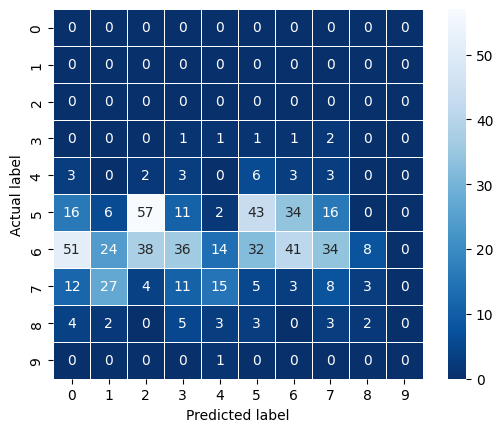

In [ ]:
# Analyse the meaning (i.e. predicted quality level) of each cluster by checking the clustering results against the true quality levels (i.e., the variable quality). Construct and explain the confusion matrix of the results.

# Create a KMeans object
kmeans = KMeans(n_clusters=k_values[best_index], random_state=0)

# Train the model using the training sets
kmeans.fit(X)

# Predict the response for test dataset
y_pred = kmeans.predict(X)

# Create a confusion matrix
cm = metrics.confusion_matrix(y, y_pred)
print(cm)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, linewidths=.5, square=True, cmap='Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()